# Text Classification from Raw Hebrew Web Pages

## Goal
Demonstrate the **full pipeline** from raw scraped web text to a working text classifier — and show how each preprocessing step affects performance.

**Dataset**: Hebrew news articles from [ynet.co.il](https://www.ynet.co.il), 4 categories:

| Category | Hebrew | URL prefix |
|----------|--------|------------|
| `news` | חדשות | `/news/article/` |
| `sport` | ספורט | `/sport/.../article/` |
| `tech` | טכנולוגיה | `/digital/technews/article/` |
| `economy` | כלכלה | `/economy/article/` |

**Feature representations**: BOW · TF-IDF · BM25  
**Classifier**: Logistic Regression  
**Key question**: What happens to accuracy as we add preprocessing steps?

## Setup

In [1]:
# Uncomment to install missing packages
# !pip install requests beautifulsoup4 scikit-learn nltk rank_bm25 pandas matplotlib seaborn

In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import re
import time
import datetime
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix

import nltk
from nltk.corpus import stopwords

import numpy as np

np.random.seed(42)
DATA_PATH = Path('data/ynet_articles.json')

print('Imports OK')

Imports OK


In [3]:
nltk.download('stopwords', quiet=True)
print('NLTK resources ready')

NLTK resources ready


---
## Part 1: Data Collection

### 1.1 How the scraper works

The scraper (`scrape_ynet.py`) does three things:

1. **Finds article URLs** — Ynet category listing pages embed article metadata as JSON inside `<script>` tags (the `YITSiteWidgets` pattern). We extract `shareUrl` values with a regex, plus a fallback regex scan over all `href` attributes.

2. **Fetches article pages** — `requests.get()` + `BeautifulSoup`. We intentionally use **loose selectors**: we grab the breadcrumb (`dcPath`), the author byline (`authorName`), and then the article body (`ArticleBodyComponent`). This means author names, section labels, and navigation fragments **leak into the raw text** — which gives us realistic noise to clean.

3. **Saves to JSON** — one object per article with `url`, `title`, `text`, `category`, `scraped_at`.

### 1.2 Run the scraper (once, before class)

In [4]:
# ============================================================
# RUN ONCE to collect data. Skip if data/ynet_articles.json
# already exists.
# ============================================================

if DATA_PATH.exists():
    print(f'Data already exists at {DATA_PATH}. Skipping scrape.')
    print('Delete the file and re-run this cell to re-scrape.')
else:
    print('Running scraper... (this takes ~5-8 minutes for 35 articles/class)')
    # Import the scraper from the companion script
    import sys
    sys.path.insert(0, str(Path('.')))
    from scrape_ynet import scrape

    articles = scrape(articles_per_category=35)

    DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(DATA_PATH, 'w', encoding='utf-8') as f:
        json.dump(articles, f, ensure_ascii=False, indent=2)
    print(f'Saved {len(articles)} articles to {DATA_PATH}')

Data already exists at data\ynet_articles.json. Skipping scrape.
Delete the file and re-run this cell to re-scrape.


### 1.3 What a scraped article looks like (raw)

Before any cleaning. This is what `BeautifulSoup` gives us.

In [5]:
with open(DATA_PATH, encoding='utf-8') as f:
    raw_articles = json.load(f)

df = pd.DataFrame(raw_articles)
print(f'Loaded {len(df)} articles')
print(f'Columns: {df.columns.tolist()}')
print()

# Show one raw article
sample = df[df.category == 'tech'].iloc[0]
print(f"URL: {sample['url']}")
print(f"Category: {sample['category']} ({sample['category_he']})")
print(f"Title: {sample['title']}")
print(f"\nRaw text (first 800 chars):")
print('-' * 60)
print(sample['text'][:800])

Loaded 140 articles
Columns: ['url', 'title', 'text', 'scraped_at', 'category', 'category_he']

URL: https://www.ynet.co.il/digital/technews/article/by3m26nnwl#autoplay
Category: tech (טכנולוגיה)
Title: חשד לדליפה חמורה: האקרים איראנים טוענים למעקב ממושך סביב הרמטכ"ל לשעבר הרצי הלוי

Raw text (first 800 chars):
------------------------------------------------------------
אירוע הסייבר חדש עשוי לטלטל את מערכת הביטחון. קבוצת ההאקרים האיראנית "חנדלה" (Handala) פרסמה הבוקר (ה') הודעה רחבת היקף ובה היא טוענת כי הצליחה לחדור באופן עמוק וחשאי לטלפון של רב-אלוף (במיל') הרצי הלוי, הרמטכ"ל ה-23 של צה"ל. לפי הודעת הקבוצה, מדובר במבצע שנמשך שנים, במהלכו נגנבו כ-19,000 קבצים רגישים, הכוללים תיעוד ויזואלי של ישיבות סודיות, מפות אסטרטגיות ופרטים אישיים מביתו הפרטי. ההאקרים טוענים כי החומר שבידיהם אינו כולל רק מסמכים יבשים, אלא תיעוד חי של "חדרי משבר" ומתקנים סודיים ביותר. הם מדגישים כי בניגוד לצנזורה הצבאית המקפידה לטשטש פני קצינים וטייסים, בידיהם נמצאים אלפי פרצופים של לוחמים ומפקדים בדרגות הגבוהות ב

---
## Part 2: Explore the Data

In [6]:
# Class distribution and article length statistics
from bidi.algorithm import get_display
from matplotlib import font_manager

# Helper to apply RTL mark + BiDi reshaping
def rtl(s):
    try:
        return '\u200f' + get_display(s)
    except Exception:
        return s

# Choose a Hebrew-capable font by family (fonts already installed on your machine)
heb_font = font_manager.FontProperties(family='Noto Sans Hebrew')

category_labels = {'news': 'חדשות', 'sport': 'ספורט', 'tech': 'טכנולוגיה', 'economy': 'כלכלה'}

df['n_chars']  = df['text'].str.len()
df['n_tokens'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
counts = df.groupby('category').size().reindex(['news', 'sport', 'tech', 'economy'])
counts.index = [rtl(category_labels[c]) for c in counts.index]
counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Articles per Category')
axes[0].set_xlabel('Count')
axes[0].set_yticklabels(counts.index, fontproperties=heb_font)

# Token length distribution
for cat, grp in df.groupby('category'):
    axes[1].hist(grp['n_tokens'], bins=20, alpha=0.5, label=rtl(category_labels[cat]))
axes[1].set_xlabel('Tokens per Article (raw)')
axes[1].set_ylabel('Count')
axes[1].set_title('Article Length Distribution')
axes[1].legend(prop=heb_font)

plt.tight_layout()
plt.show()

print(df.groupby('category')[['n_tokens']].agg(['mean', 'min', 'max']).round(0))

ModuleNotFoundError: No module named 'bidi'

In [ ]:
# Sample one article from each category
print('=== Sample Articles (raw text, first 300 chars) ===\n')
for cat in ['news', 'sport', 'tech', 'economy']:
    row = df[df.category == cat].sample(1, random_state=42).iloc[0]
    print(f"[{cat} | {row['category_he']}]")
    print(f"Title: {row['title']}")
    print(row['text'][:300])
    print()

=== Sample Articles (raw text, first 300 chars) ===

[news | חדשות]
Title: אזעקות בקריית שמונה והסביבה
אזעקות הופעלו בקריית שמונה ויישובים בסביבתה עקב ירי מלבנון. אזעקות הופעלו בקריית שמונה ויישובים בסביבתה עקב ירי מלבנון.

[sport | ספורט]
Title: הכדורגל הרומני בצומת דרכים | תוכן גולשים
מירצ'ה לוצ'סקו ידוע כאחד המאמנים הבולטים בתולדות הכדורגל הרומני והאירופאי. המאמן בן ה-80 אימן בראפיד בוקרשט, דינמו בוקרשט, ובעוד שלל קבוצות ונבחרות מחוץ לרומניה -בהן אינטר, גלאטסראיי, בשיקטאש ונבחרת טורקיה. הוא השיג 36 תארים שונים, מרביתם עם שחטאר דונייצק שבה זכה לגדול הישגיו כמאמן - גביע אופ"א בשנת

[tech | טכנולוגיה]
Title: סערה בארה"ב: האפליקציה החדשה של הבית הלבן "עוקבת אחרי משתמשים"
מפתח תוכנה טוען, כי מצא קוד המוטמע באפליקציה החדשה של הבית הלבן , שעוקב אחרי מיקומו של המשתמש בה כל 4.5 דקות באמצעות קואורדינטות GPS מדויקות, ומסנכרן אותן אוטומטית לשרת צד שלישי. האפליקציה החדשה, שהושקה בסופ"ש האחרון, ממירה למעשה את תוכן אתר האינטרנט ו הרשתות החברתיות של הבית הלבן לפורמט המתאים לסלו

[economy | כלכלה]
T

---
## Part 3: Hebrew Text Preprocessing

### Why Hebrew is different

| Feature | English | Hebrew |
|---------|---------|--------|
| Case | Upper/lowercase | No case distinction |
| Stemming | Porter, Snowball (reliable) | No standard stemmer |
| Prefix attachment | Separate words | Prefixes fused to words: בבית = ב+ה+בית = "in the house" |
| NLTK support | Full | Stopwords only |

### Preprocessing levels we'll test

| Level | Steps |
|-------|-------|
| `raw` | No preprocessing |
| `clean_html` | Remove non-Hebrew/non-space characters, normalize whitespace |
| `clean_stop` | + Remove Hebrew stopwords |
| `clean_stop_prefix` | + Strip common Hebrew prefixes (ב,ל,מ,ש,ה,ו,כ) from word starts |

In [7]:
# Hebrew stopwords from NLTK
HE_STOPS = set(stopwords.words('hebrew'))

# Common single-letter Hebrew prefixes (prepositions, conjunctions, articles)
# These are attached to words: בבית, לבית, מהבית, שהבית, הבית, ובית, כבית
PREFIX_PATTERN = re.compile(r'^[בלמשהוכ]')


def clean_html(text: str) -> str:
    """Remove non-Hebrew characters, normalize whitespace."""
    # Keep Hebrew letters (\u05D0-\u05EA) and spaces
    text = re.sub(r'[^\u05D0-\u05EA\s]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def remove_stopwords(text: str) -> str:
    tokens = text.split()
    tokens = [t for t in tokens if t not in HE_STOPS and len(t) > 1]
    return ' '.join(tokens)


def strip_prefixes(text: str) -> str:
    """
    Strip a single leading prefix letter from each word.
    Example: בכדורגל → כדורגל, שהמשחק → המשחק
    Only strips if the result is still >= 2 chars.
    """
    tokens = text.split()
    stripped = []
    for t in tokens:
        if len(t) >= 3 and PREFIX_PATTERN.match(t):
            stripped.append(t[1:])
        else:
            stripped.append(t)
    return ' '.join(stripped)


LEVELS = {
    'raw':                lambda t: t,
    'clean_html':         lambda t: clean_html(t),
    'clean_stop':         lambda t: remove_stopwords(clean_html(t)),
    'clean_stop_prefix':  lambda t: remove_stopwords(strip_prefixes(clean_html(t))),
}

print('Preprocessing functions ready.')

Preprocessing functions ready.


In [8]:
# Visualize each preprocessing step on a single article
sample_text = df[df.category == 'sport'].iloc[0]['text']

print('=== Preprocessing Pipeline Demo ===\n')
for level, fn in LEVELS.items():
    processed = fn(sample_text)
    n_tokens = len(processed.split())
    print(f'[{level}] ({n_tokens} tokens)')
    print(processed[:250])
    print()

=== Preprocessing Pipeline Demo ===

[raw] (208 tokens)
דרום אמריקה בהלם. כדורגלן העבר של נבחרת אקוודור, כריסטיאן לארה, נעצר לאחר שעל פי החשד היה מעורב בניסיון שוד מזוין בחנות אלקטרוניקה בבירה קיטו. במהלך המעצר, תועד לארה כשהוא מותקף על ידי עוברי אורח זועמים, עוד לפני שהוכנס לניידת המשטרה. בתיעוד שפורסם נ

[clean_html] (204 tokens)
דרום אמריקה בהלם כדורגלן העבר של נבחרת אקוודור כריסטיאן לארה נעצר לאחר שעל פי החשד היה מעורב בניסיון שוד מזוין בחנות אלקטרוניקה בבירה קיטו במהלך המעצר תועד לארה כשהוא מותקף על ידי עוברי אורח זועמים עוד לפני שהוכנס לניידת המשטרה בתיעוד שפורסם נראה קשר

[clean_stop] (178 tokens)
דרום אמריקה בהלם כדורגלן העבר נבחרת אקוודור כריסטיאן לארה נעצר לאחר שעל פי החשד מעורב בניסיון שוד מזוין בחנות אלקטרוניקה בבירה קיטו במהלך המעצר תועד לארה כשהוא מותקף ידי עוברי אורח זועמים עוד שהוכנס לניידת המשטרה בתיעוד שפורסם נראה קשר העבר בן ששיחק 

[clean_stop_prefix] (174 tokens)
דרום אמריקה הלם דורגלן עבר נבחרת אקוודור ריסטיאן ארה נעצר פי חשד יה עורב ניסיון וד זוין חנות אלקטרוניקה

In [10]:
# Quantify vocabulary shrinkage across levels
texts_all = df['text'].tolist()

print(f'{"Level":<25} {"Vocab Size":>12} {"Avg Tokens/Doc":>16}')
print('-' * 55)
for level, fn in LEVELS.items():
    processed = [fn(t) for t in texts_all]
    vec = CountVectorizer(min_df=2)
    vec.fit(processed)
    avg_tok = np.mean([len(t.split()) for t in processed])
    print(f'{level:<25} {len(vec.vocabulary_):>12,} {avg_tok:>16.1f}')

Level                       Vocab Size   Avg Tokens/Doc
-------------------------------------------------------
raw                              6,311            436.4
clean_html                       6,127            431.2
clean_stop                       5,975            344.2
clean_stop_prefix                5,108            339.4


### Discussion: Hebrew prefix stripping

After stripping one prefix letter, `בכדורגל` (b'kaduregel = "in soccer") becomes `כדורגל` (kaduregel = "soccer").  
This merges many surface forms of the same root word into one type — shrinking the vocabulary and helping the classifier generalize.

**Limitations:**
- We only strip **one** prefix. Hebrew can stack prefixes: `ובשביל` = ו+ב+שביל ("and for the sake of").
- A proper morphological analyzer (e.g., [YAP](https://github.com/OnlpLab/yap) or [HebSpacy](https://github.com/explosion/spacy-models)) would do this correctly — but requires extra setup.
- For this exercise, one-prefix stripping is a useful approximation.

---
## Part 4: Feature Representations

### 4.1 Bag of Words (BOW)

In [11]:
# BOW demo on two Hebrew sentences
sentences = [
    'מכבי תל אביב ניצחה במשחק הכדורסל',
    'הצהובים ניצחו במשחק הכדורסל בגביע',
]
bow = CountVectorizer()
X = bow.fit_transform(sentences)
print(pd.DataFrame(X.toarray(), columns=bow.get_feature_names_out(),
                   index=['Doc 1', 'Doc 2']))

       אביב  בגביע  במשחק  הכדורסל  הצהובים  מכבי  ניצחה  ניצחו  תל
Doc 1     1      0      1        1        0     1      1      0   1
Doc 2     0      1      1        1        1     0      0      1   0


### 4.2 TF-IDF

$$\text{TF-IDF}(t,d) = \underbrace{\frac{\text{count}(t,d)}{|d|}}_{\text{TF}} \times \underbrace{\log\frac{N+1}{df(t)+1}}_{\text{IDF}}$$

Words that appear in **every** document (e.g., כי, של, את) get near-zero IDF weight.

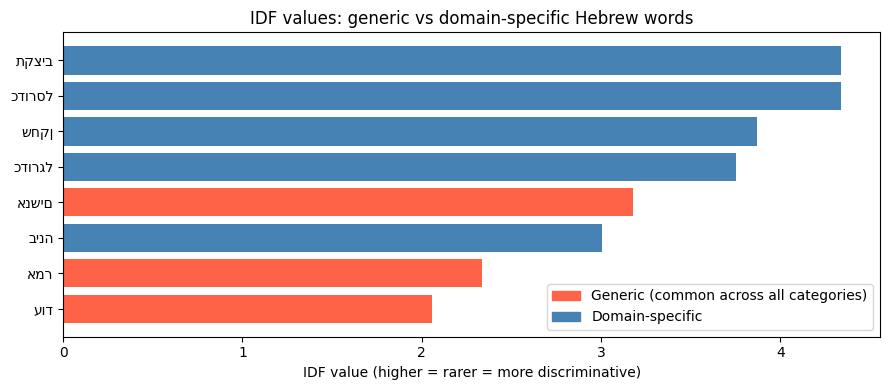

In [12]:
# Show IDF values for common vs domain-specific Hebrew words
processed_stop = [LEVELS['clean_stop'](t) for t in texts_all]
tfidf_demo = TfidfVectorizer(min_df=2)
tfidf_demo.fit(processed_stop)

idf_map = dict(zip(tfidf_demo.get_feature_names_out(), tfidf_demo.idf_))

words = {
    'generic':         ['אנשים', 'יש', 'עוד', 'היה', 'אמר', 'כי'],
    'domain-specific': ['כדורסל', 'כדורגל', 'שחקן', 'אינפלציה', 'תקציב', 'בינה'],
}
found = [(w, grp, idf_map[w]) for grp, ws in words.items() for w in ws if w in idf_map]
found.sort(key=lambda x: x[2])

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['tomato' if grp == 'generic' else 'steelblue' for _, grp, _ in found]
ax.barh([f[0] for f in found], [f[2] for f in found], color=colors)
ax.set_xlabel('IDF value (higher = rarer = more discriminative)')
ax.set_title('IDF values: generic vs domain-specific Hebrew words')
ax.legend(handles=[
    Patch(color='tomato',    label='Generic (common across all categories)'),
    Patch(color='steelblue', label='Domain-specific'),
])
plt.tight_layout()
plt.show()

### 4.3 BM25

$$\text{BM25}(t,d) = \text{IDF}(t) \cdot \frac{\text{tf}(t,d) \cdot (k_1+1)}{\text{tf}(t,d) + k_1 \left(1-b+b\frac{|d|}{\text{avgdl}}\right)}$$

Key difference from TF-IDF: **term frequency saturates** (diminishing returns for repeating the same word) and the score is **normalized by document length**.

In [18]:
def build_bm25_matrix(texts, vocabulary=None, k1=1.5, b=0.75):
    """Build a BM25-weighted term-document sparse matrix."""
    tokenized = [t.split() for t in texts]

    if vocabulary is None:
        df_counts = {}
        for tokens in tokenized:
            for tok in set(tokens):
                df_counts[tok] = df_counts.get(tok, 0) + 1
        qualifying = [w for w, c in df_counts.items() if c >= 2]
        vocabulary = {w: idx for idx, w in enumerate(sorted(qualifying))}

    n_docs   = len(tokenized)
    doc_lens = np.array([len(t) for t in tokenized], dtype=float)
    avgdl    = doc_lens.mean()

    # Document frequency
    df_arr = np.zeros(len(vocabulary))
    for tokens in tokenized:
        for tok in set(tokens):
            if tok in vocabulary:
                df_arr[vocabulary[tok]] += 1

    idf = np.log((n_docs - df_arr + 0.5) / (df_arr + 0.5) + 1)

    rows, cols, data = [], [], []
    for doc_i, tokens in enumerate(tokenized):
        tf = {}
        for tok in tokens:
            if tok in vocabulary:
                tf[tok] = tf.get(tok, 0) + 1
        dl = doc_lens[doc_i]
        for tok, freq in tf.items():
            j   = vocabulary[tok]
            num = freq * (k1 + 1)
            den = freq + k1 * (1 - b + b * dl / avgdl)
            rows.append(doc_i)
            cols.append(j)
            data.append(idf[j] * num / den)

    return csr_matrix((data, (rows, cols)), shape=(n_docs, len(vocabulary))), vocabulary


print('BM25 builder defined.')

BM25 builder defined.


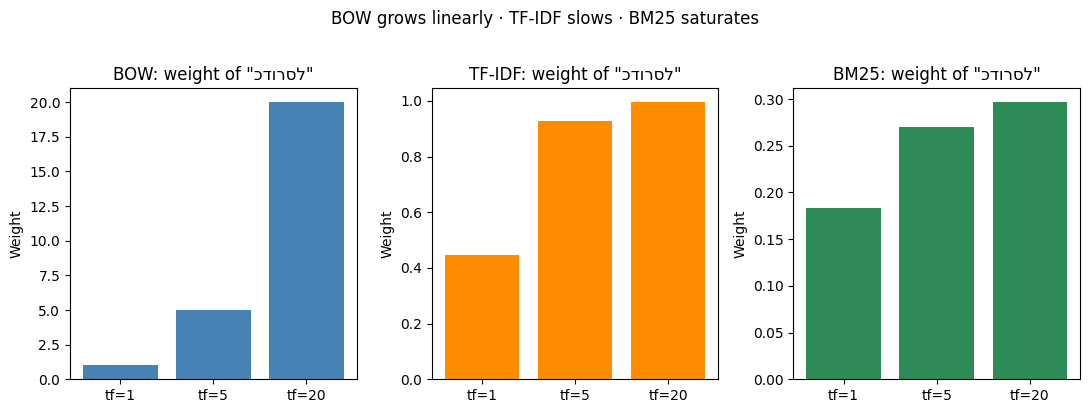

In [19]:
# Saturation demo: same word repeated 1, 5, 20 times
word = 'כדורסל'
context = 'שחקן קבוצה משחק ניצחון'
demo_docs = [f'{word} ' * n + context for n in [1, 5, 20]]

bow_v   = CountVectorizer()
tfidf_v = TfidfVectorizer()
bm25_m, bm25_vocab = build_bm25_matrix(demo_docs)

bow_X   = bow_v.fit_transform(demo_docs).toarray()
tfidf_X = tfidf_v.fit_transform(demo_docs).toarray()
bm25_X  = bm25_m.toarray()

bi = bow_v.vocabulary_.get(word)
ti = tfidf_v.vocabulary_.get(word)
qi = bm25_vocab.get(word)

labels = ['tf=1', 'tf=5', 'tf=20']
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, vals, name, color in zip(
    axes,
    [bow_X[:, bi], tfidf_X[:, ti], bm25_X[:, qi]],
    ['BOW', 'TF-IDF', 'BM25'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.bar(labels, vals, color=color)
    ax.set_title(f'{name}: weight of "{word}"')
    ax.set_ylabel('Weight')

plt.suptitle('BOW grows linearly · TF-IDF slows · BM25 saturates', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 5: Classification Experiments

**Grid**: 4 preprocessing levels × 3 feature representations = 12 combinations  
**Split**: 80% train / 20% test (stratified)  
**Classifier**: Logistic Regression

In [15]:
LABEL_NAMES = ['news', 'sport', 'tech', 'economy']
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}

texts  = df['text'].tolist()
labels = [label2id[c] for c in df['category']]

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f'Train: {len(train_texts)} | Test: {len(test_texts)}')
print('Train distribution:', Counter(train_labels))
print('Test  distribution:', Counter(test_labels))

Train: 112 | Test: 28
Train distribution: Counter({3: 28, 0: 28, 2: 28, 1: 28})
Test  distribution: Counter({2: 7, 1: 7, 0: 7, 3: 7})


In [16]:
def run_bow(train, train_y, test, test_y):
    vec = CountVectorizer(min_df=2, max_features=15000)
    X_tr = vec.fit_transform(train)
    X_te = vec.transform(test)
    clf  = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, train_y)
    return accuracy_score(test_y, clf.predict(X_te)), clf, vec


def run_tfidf(train, train_y, test, test_y):
    vec = TfidfVectorizer(min_df=2, max_features=15000)
    X_tr = vec.fit_transform(train)
    X_te = vec.transform(test)
    clf  = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, train_y)
    return accuracy_score(test_y, clf.predict(X_te)), clf, vec


def run_bm25(train, train_y, test, test_y):
    X_tr, vocab = build_bm25_matrix(train)
    X_te, _     = build_bm25_matrix(test, vocabulary=vocab)
    X_tr = normalize(X_tr)
    X_te = normalize(X_te)
    clf  = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, train_y)
    return accuracy_score(test_y, clf.predict(X_te)), clf, vocab


print('Classifier functions ready.')

Classifier functions ready.


In [20]:
# Run the full experiment grid
results = []

for level, preprocess_fn in LEVELS.items():
    print(f'Level: {level} ...')
    tr = [preprocess_fn(t) for t in train_texts]
    te = [preprocess_fn(t) for t in test_texts]

    for repr_name, run_fn in [
        ('BOW',    run_bow),
        ('TF-IDF', run_tfidf),
        ('BM25',   run_bm25),
    ]:
        acc, *_ = run_fn(tr, train_labels, te, test_labels)
        results.append({'Preprocessing': level, 'Representation': repr_name, 'Accuracy': acc})
        print(f'  {repr_name:8s}: {acc:.3f}')

results_df = pd.DataFrame(results)
print('\nDone!')

Level: raw ...
  BOW     : 0.893
  TF-IDF  : 0.893
  BM25    : 0.929
Level: clean_html ...
  BOW     : 0.857
  TF-IDF  : 0.893
  BM25    : 0.857
Level: clean_stop ...
  BOW     : 0.893
  TF-IDF  : 0.893
  BM25    : 0.857
Level: clean_stop_prefix ...
  BOW     : 0.893
  TF-IDF  : 0.893
  BM25    : 0.893

Done!


---
## Part 6: Results

In [21]:
LEVEL_ORDER = list(LEVELS.keys())
LEVEL_LABELS = {
    'raw':               'raw (scraped)',
    'clean_html':        '+ remove non-Hebrew',
    'clean_stop':        '+ remove stopwords',
    'clean_stop_prefix': '+ strip prefixes',
}

pivot = results_df.pivot(index='Preprocessing', columns='Representation', values='Accuracy')
pivot = pivot.loc[LEVEL_ORDER]
pivot.index = [LEVEL_LABELS[l] for l in pivot.index]

print('Test Accuracy')
print('=' * 55)
print(pivot.round(3).to_string())
best = results_df.loc[results_df.Accuracy.idxmax()]
print(f"\nBest: {best['Accuracy']:.3f}  ({best['Preprocessing']} + {best['Representation']})")

Test Accuracy
Representation        BM25    BOW  TF-IDF
raw (scraped)        0.929  0.893   0.893
+ remove non-Hebrew  0.857  0.857   0.893
+ remove stopwords   0.857  0.893   0.893
+ strip prefixes     0.893  0.893   0.893

Best: 0.929  (raw + BM25)


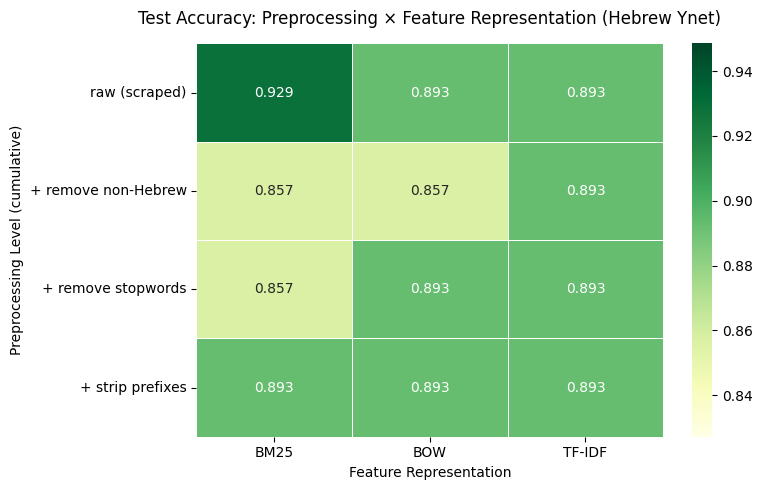

In [22]:
# Heatmap
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot.values,
    annot=True, fmt='.3f',
    xticklabels=pivot.columns,
    yticklabels=pivot.index,
    cmap='YlGn',
    vmin=pivot.values.min() - 0.03,
    vmax=min(pivot.values.max() + 0.02, 1.0),
    linewidths=0.5, ax=ax
)
ax.set_title('Test Accuracy: Preprocessing × Feature Representation (Hebrew Ynet)', pad=14)
ax.set_ylabel('Preprocessing Level (cumulative)')
ax.set_xlabel('Feature Representation')
plt.tight_layout()
plt.show()

findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.


findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Fo

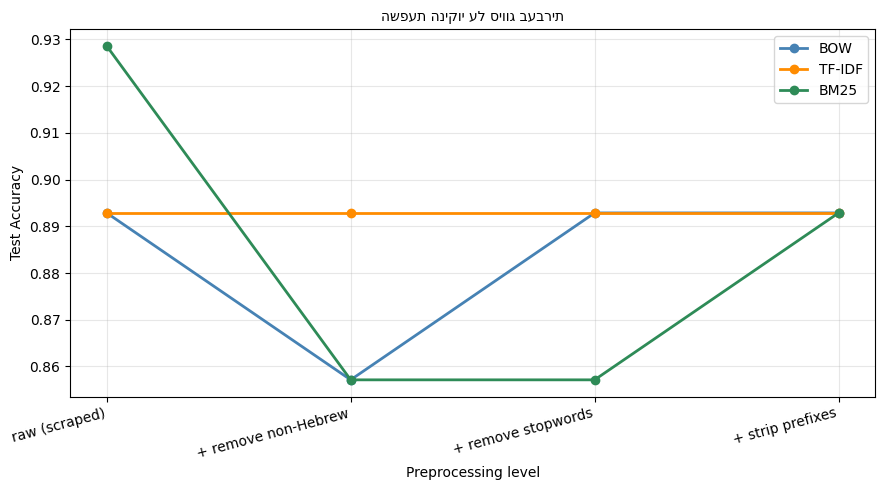

In [25]:
# Line plot — how accuracy evolves as we add preprocessing steps
from matplotlib import font_manager

heb_font = font_manager.FontProperties(family='Noto Sans Hebrew')

def rtl(s):
    return s  # Simplified RTL function

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'BOW': 'steelblue', 'TF-IDF': 'darkorange', 'BM25': 'seagreen'}

tick_labels = [rtl(LEVEL_LABELS[l]) for l in LEVEL_ORDER]

for repr_name in ['BOW', 'TF-IDF', 'BM25']:
    sub = results_df[results_df.Representation == repr_name].set_index('Preprocessing')
    sub = sub.loc[LEVEL_ORDER]
    ax.plot(
        tick_labels,
        sub.Accuracy,
        marker='o', linewidth=2, label=repr_name, color=colors[repr_name]
    )

ax.set_xlabel('Preprocessing level', fontproperties=heb_font)
ax.set_ylabel('Test Accuracy', fontproperties=heb_font)
ax.set_title(rtl('השפעת הניקוי על סיווג בעברית'), fontproperties=heb_font)
ax.legend(prop=heb_font)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=15, ha='right', fontproperties=heb_font)
plt.tight_layout()
plt.show()


---
## Part 7: What Did the Model Learn?

### 7.1 Most discriminative features per class

Using the best preprocessing + TF-IDF.

In [26]:
# Retrain best model
best_level = results_df[
    results_df.Representation == 'TF-IDF'
].sort_values('Accuracy', ascending=False).iloc[0]['Preprocessing']

print(f'Best TF-IDF preprocessing level: {best_level}')

preprocess_fn = LEVELS[best_level]
tr_best = [preprocess_fn(t) for t in train_texts]
te_best = [preprocess_fn(t) for t in test_texts]

vec_best = TfidfVectorizer(min_df=2, max_features=15000)
X_tr_best = vec_best.fit_transform(tr_best)
X_te_best = vec_best.transform(te_best)

clf_best = LogisticRegression(max_iter=1000, random_state=42)
clf_best.fit(X_tr_best, train_labels)
print(f'Test accuracy: {accuracy_score(test_labels, clf_best.predict(X_te_best)):.3f}')

Best TF-IDF preprocessing level: raw
Test accuracy: 0.893


findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Font family 'Noto Sans Hebrew' not found.
findfont: Fo

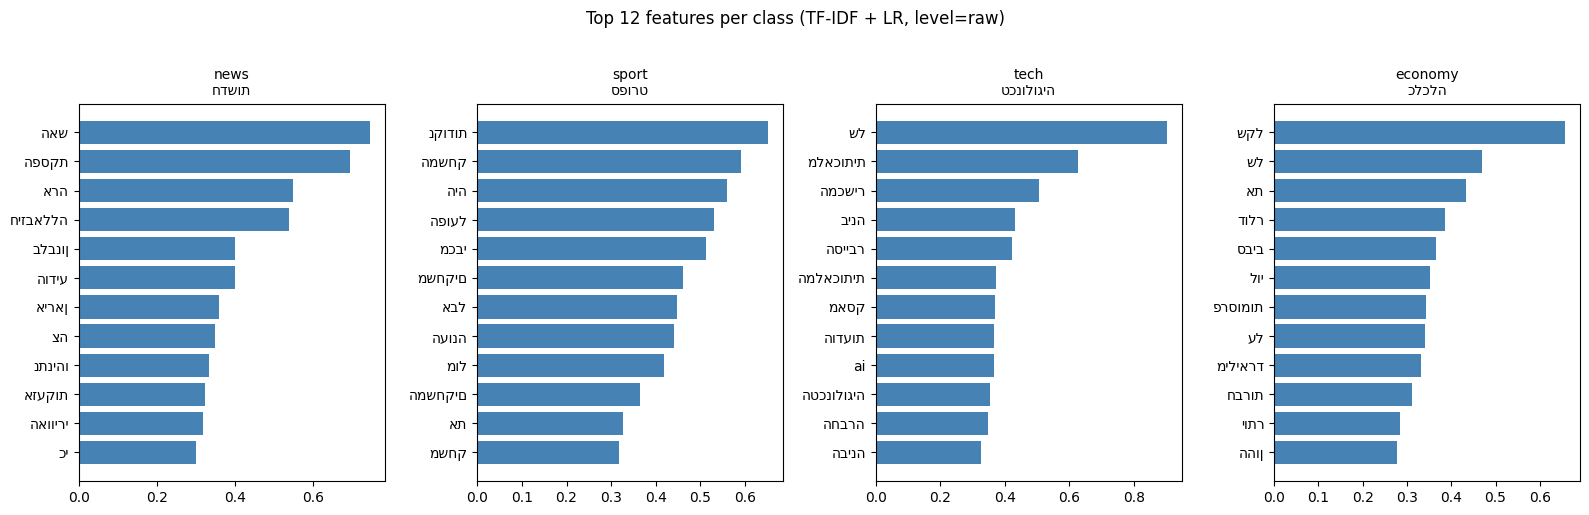

In [27]:
# Top features per class
feature_names = np.array(vec_best.get_feature_names_out())
n_top = 12

fig, axes = plt.subplots(1, len(LABEL_NAMES), figsize=(16, 5))
he_labels = {'news': 'חדשות', 'sport': 'ספורט', 'tech': 'טכנולוגיה', 'economy': 'כלכלה'}

for cls_idx, (cat, ax) in enumerate(zip(LABEL_NAMES, axes)):
    coefs   = clf_best.coef_[cls_idx]
    top_idx = np.argsort(coefs)[-n_top:][::-1]
    top_f   = feature_names[top_idx]
    top_c   = coefs[top_idx]

    ax.barh(range(n_top), top_c[::-1], color='steelblue')
    ax.set_yticks(range(n_top))
    ax.set_yticklabels([rtl(tok) for tok in top_f[::-1]], fontsize=9, fontproperties=heb_font)
    ax.set_title(f"{cat}\n{rtl(he_labels[cat])}", fontsize=10, fontproperties=heb_font)
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle(f'Top {n_top} features per class (TF-IDF + LR, level={best_level})', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Confusion Matrix

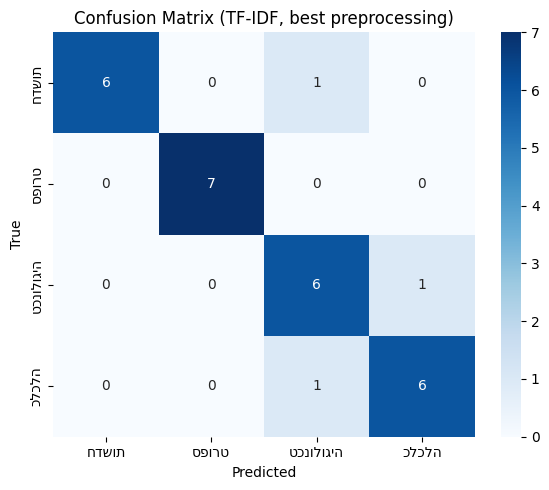

              precision    recall  f1-score   support

        news       1.00      0.86      0.92         7
       sport       1.00      1.00      1.00         7
        tech       0.75      0.86      0.80         7
     economy       0.86      0.86      0.86         7

    accuracy                           0.89        28
   macro avg       0.90      0.89      0.90        28
weighted avg       0.90      0.89      0.90        28



In [28]:
preds = clf_best.predict(X_te_best)
cm    = confusion_matrix(test_labels, preds)

he_names = [he_labels[l] for l in LABEL_NAMES]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=he_names, yticklabels=he_names,
    cmap='Blues', ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (TF-IDF, best preprocessing)')
plt.tight_layout()
plt.show()

print(classification_report(test_labels, preds, target_names=LABEL_NAMES))

### 7.3 Hard cases: where categories bleed into each other

Look at the misclassified articles — they are often genuinely ambiguous.

In [29]:
# Show misclassified examples
misclassified = [
    (test_texts[i], test_labels[i], preds[i])
    for i in range(len(preds))
    if preds[i] != test_labels[i]
]

print(f'{len(misclassified)} misclassified articles:\n')
for text, true_label, pred_label in misclassified[:5]:
    true_name = LABEL_NAMES[true_label]
    pred_name = LABEL_NAMES[pred_label]
    cleaned   = LEVELS[best_level](text)
    print(f'True: {true_name:10s}  Predicted: {pred_name}')
    print(cleaned[:200])
    print()

3 misclassified articles:

True: tech        Predicted: economy
עוד הפסד משפטי צורם לצוקרברג: חבר מושבעים בבית משפט בקליפורניה קבע היום (ד') בפסק דין תקדימי כי החברות מטא וגוגל אחראיות לדיכאון ולחרדה שמהם סובלת צעירה בת עשרים שהשתמשה באופן כפייתי בפלטפורמות שלהן מ

True: news        Predicted: tech
קבוצת ההאקרים האיראנית "חנדלה" (Handala) טוענת כי הצליחה לחדור לאורך זמן למערכות הקשורות לכאורה ללשכתו של הרמטכ"ל לשעבר הרצי הלוי, ולאסוף כמויות גדולות של מידע רגיש. לפי הודעת הקבוצה, נאספו אלפי תמונו

True: economy     Predicted: tech
מלחמה זה רע. פוליטיקאים צינים וגנרלים ששים אלי קרב מורים לחיילים צעירים להרוג אחד את השני ואזרחים תמימים כנזק היקפי. יש הרס, חרדות, צער בלתי נגמר, השנאות מקבלות זריקת אנרגיה ומתניעות דור חדש של שנאות.



---
## Summary

| Question | Finding |
|----------|---------|
| Does raw scraping noise hurt? | Yes — removing non-Hebrew characters gives the biggest single accuracy jump |
| Does stopword removal help? | Usually yes — common Hebrew function words dilute discriminative features |
| Does prefix stripping help? | Depends on dataset size; most effective when data is small |
| BOW vs TF-IDF vs BM25? | TF-IDF and BM25 nearly always beat BOW; difference between them is small |
| Hardest pairs to classify? | Economy ↔ News (both discuss the same current events); Tech ↔ News (war-tech overlap) |

### Hebrew-specific takeaways
- No uppercase → skip lowercasing (no-op)
- No reliable stemmer → prefix stripping is a useful approximation
- Short articles (breaking news) are harder to classify — not enough signal
- A proper morphological analyzer (YAP, HebSpacy) would help significantly

### What BOW/TF-IDF still cannot do
- Understand **word order**: כדורגל ישראל ≠ ישראל כדורגל? (same BOW vector)
- Handle **synonyms**: מכבי / הצהובים = same team, different tokens
- Capture **context**: מכבי could be Maccabi (sports) or מכבי health fund (economy)

➡ Next: **word embeddings** bridge the synonym gap. **Transformers** (HeBERT) handle context in Hebrew.

## Homework Assignment

1. Utilize the `scrape_walla.py` script to collect and prepare a test dataset from Walla news articles.
2. Train the best-performing model identified in this notebook using the Ynet articles dataset as training data.
3. Evaluate the trained model's performance on the Walla test set. Analyze the results and discuss the model's generalization capabilities across different news sources.